<a href="https://colab.research.google.com/github/Phalguni-dhabale/MV-LAB/blob/main/PRATICAL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving P2.png to P2.png


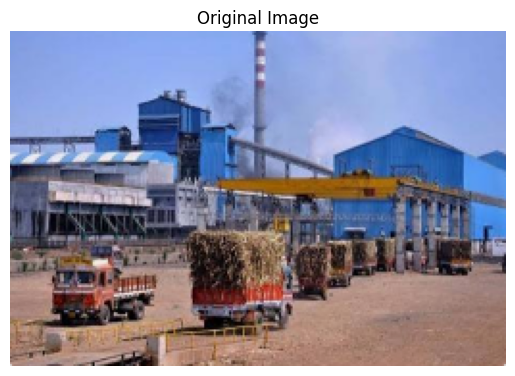

In [3]:
img = cv2.imread(list(uploaded.keys())[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [4]:
print("Image Shape:", img.shape)
print("Height:", img.shape[0])
print("Width :", img.shape[1])
print("Channels:", img.shape[2])

Image Shape: (174, 258, 3)
Height: 174
Width : 258
Channels: 3


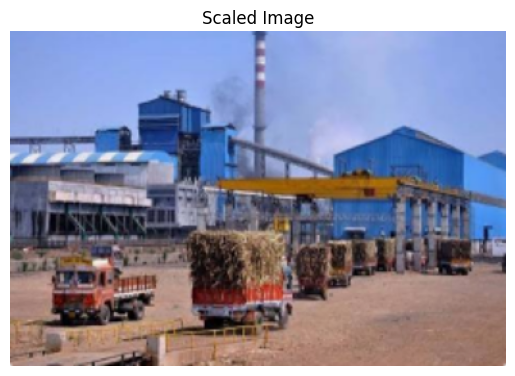

In [5]:
scaled = cv2.resize(img, None, fx=1.5, fy=1.5)

plt.imshow(scaled)
plt.title("Scaled Image")
plt.axis("off")
plt.show()

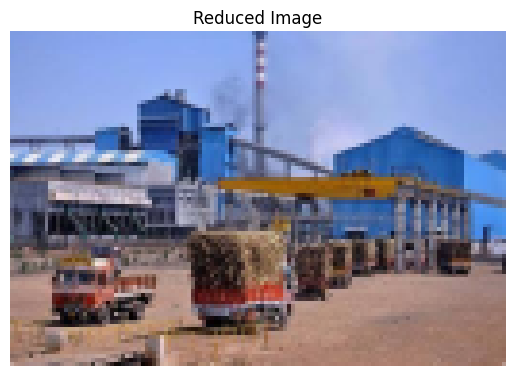

In [6]:
small = cv2.resize(img, None, fx=0.5, fy=0.5)

plt.imshow(small)
plt.title("Reduced Image")
plt.axis("off")
plt.show()

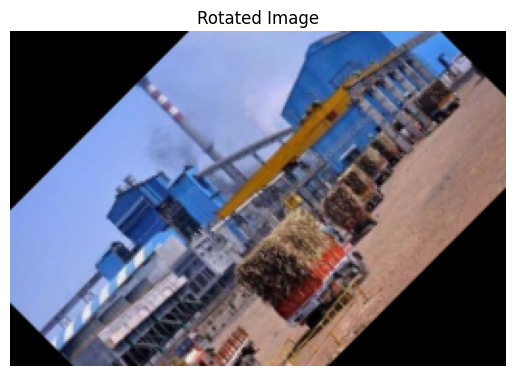

In [7]:
(h, w) = img.shape[:2]

center = (w//2, h//2)

matrix = cv2.getRotationMatrix2D(center,45,1)

rotated = cv2.warpAffine(img,matrix,(w,h))

plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis("off")
plt.show()

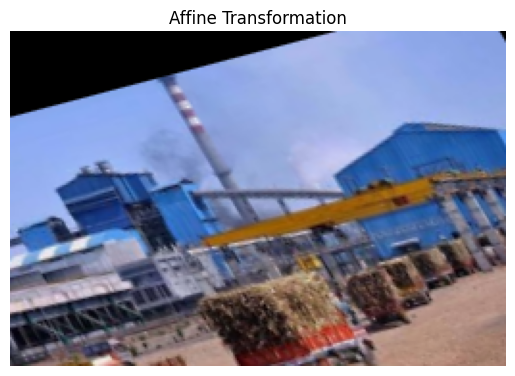

In [8]:
rows, cols = img.shape[:2]

pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])

matrix = cv2.getAffineTransform(pts1,pts2)

affine = cv2.warpAffine(img,matrix,(cols,rows))

plt.imshow(affine)
plt.title("Affine Transformation")
plt.axis("off")
plt.show()

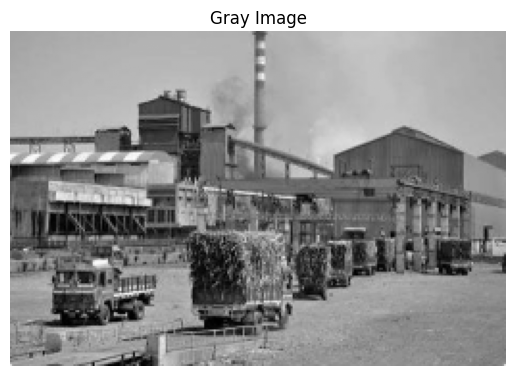

In [9]:
gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)

plt.imshow(gray,cmap='gray')
plt.title("Gray Image")
plt.axis("off")
plt.show()

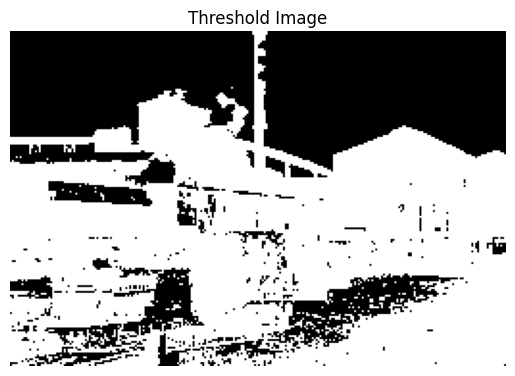

In [10]:
_, thresh = cv2.threshold(gray,150,255,cv2.THRESH_BINARY_INV)

plt.imshow(thresh,cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

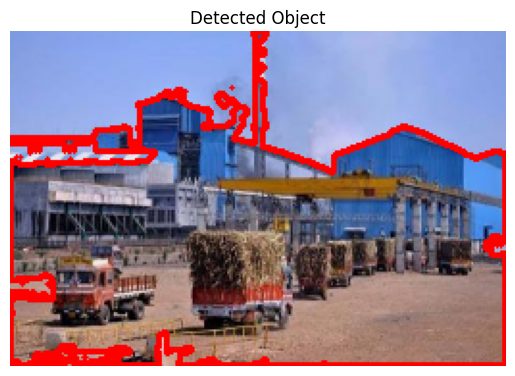

In [11]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

image_copy = img.copy()

cv2.drawContours(image_copy, contours, -1, (255,0,0), 2)

plt.imshow(image_copy)
plt.title("Detected Object")
plt.axis("off")
plt.show()

In [12]:
for cnt in contours:

    x,y,w,h = cv2.boundingRect(cnt)

    cv2.rectangle(image_copy,(x,y),(x+w,y+h),(0,255,0),2)

    print("Width (pixels):",w)
    print("Height (pixels):",h)

Width (pixels): 2
Height (pixels): 1
Width (pixels): 2
Height (pixels): 1
Width (pixels): 1
Height (pixels): 1
Width (pixels): 1
Height (pixels): 2
Width (pixels): 3
Height (pixels): 1
Width (pixels): 1
Height (pixels): 1
Width (pixels): 1
Height (pixels): 1
Width (pixels): 1
Height (pixels): 1
Width (pixels): 1
Height (pixels): 1
Width (pixels): 1
Height (pixels): 1
Width (pixels): 1
Height (pixels): 1
Width (pixels): 1
Height (pixels): 1
Width (pixels): 258
Height (pixels): 174


In [13]:
pixels_per_cm = 50

width_cm = w / pixels_per_cm
height_cm = h / pixels_per_cm

print("Estimated Width:", round(width_cm,2),"cm")
print("Estimated Height:", round(height_cm,2),"cm")

Estimated Width: 5.16 cm
Estimated Height: 3.48 cm
